# 📦 Step 1: Load & Understand the Sales Dataset

This project uses a simulated Walmart-style dataset containing monthly sales data from 2018 to 2022 across:

- **3 stores**: Boston Central, Austin North, San Diego East  
- **3 departments**: Groceries, Electronics, Home & Living

Each row represents the total sales for a store–department pair in a given month.

### Columns:
- `date`: Start of the month
- `store`: Store name
- `department`: Product category
- `sales`: Total sales in USD

We'll forecast overall monthly sales using Prophet and evaluate performance on the last 12 months of data.

In [32]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("walmart_sales.csv")
df["date"] = pd.to_datetime(df["date"])

# Preview the data
df.head()

,date,store,department,sales
0,2018-01-01,Boston Central,Groceries,33571
1,2018-02-01,Boston Central,Groceries,37228
2,2018-03-01,Boston Central,Groceries,37923
3,2018-04-01,Boston Central,Groceries,40121
4,2018-05-01,Boston Central,Groceries,37615


# 📊 Step 2: Exploratory Data Analysis (EDA)

We start by understanding how sales change over time:

- Overall trend from 2018 to 2022
- Seasonal patterns by month
- Store-wise and department-wise variations

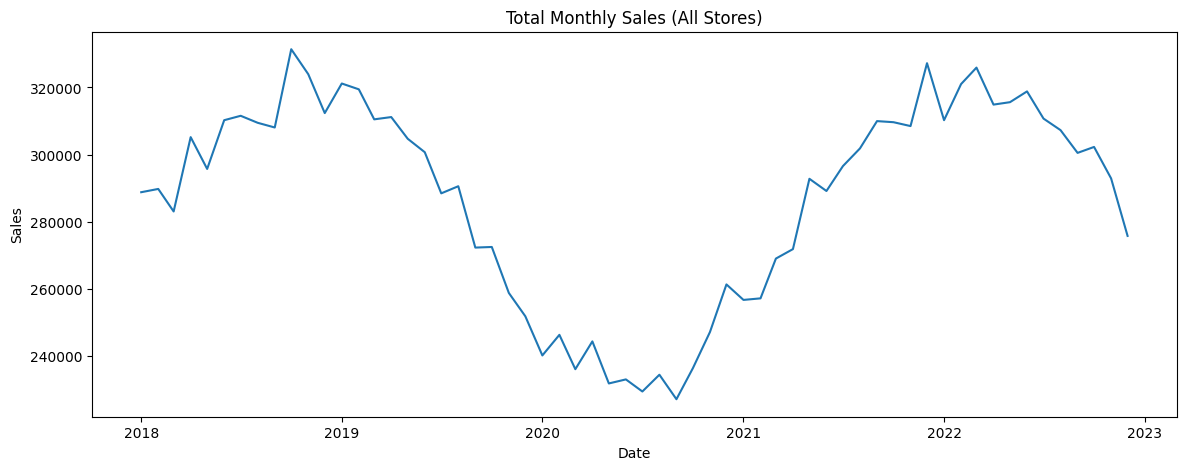

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Total sales per month
monthly_sales = df.groupby("date")["sales"].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_sales, x="date", y="sales")
plt.title("Total Monthly Sales (All Stores)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

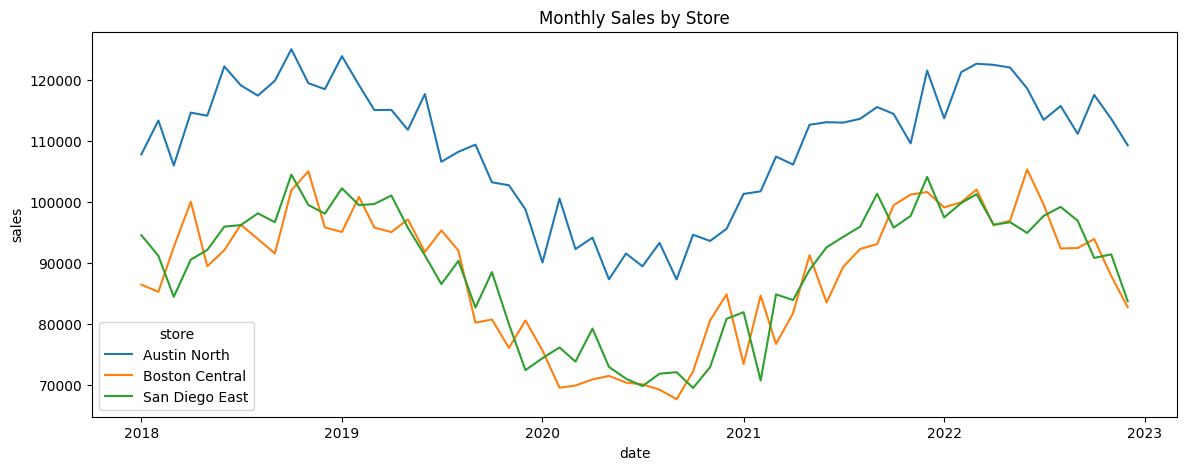

In [34]:
# Sales by store
store_sales = df.groupby(["date", "store"])["sales"].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=store_sales, x="date", y="sales", hue="store")
plt.title("Monthly Sales by Store")
plt.show()

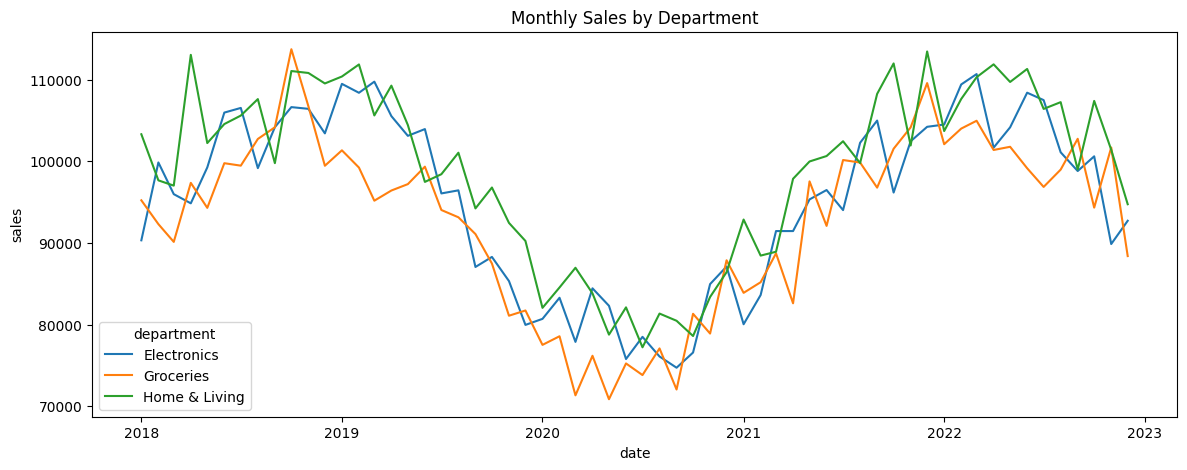

In [35]:
# Sales by department
dept_sales = df.groupby(["date", "department"])["sales"].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=dept_sales, x="date", y="sales", hue="department")
plt.title("Monthly Sales by Department")
plt.show()

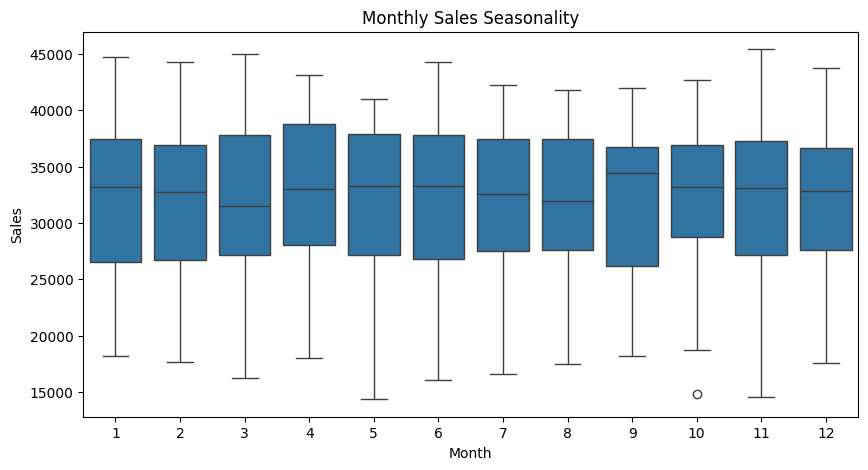

In [36]:
# Monthly seasonality (boxplot)
df["month"] = df["date"].dt.month
plt.figure(figsize=(10, 5))
sns.boxplot(x="month", y="sales", data=df)
plt.title("Monthly Sales Seasonality")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# 🔮 Step 3: Forecasting Monthly Sales with Prophet

We use Facebook Prophet to forecast the next 12 months of total monthly sales.

Steps:
- Aggregate all stores and departments together
- Fit Prophet model on data before 2022
- Forecast for 2023

In [37]:
from prophet import Prophet

# Prepare monthly data
monthly = df.groupby("date")["sales"].sum().reset_index()
monthly.columns = ["ds", "y"]

# Train/test split
train = monthly[:-12]
test = monthly[-12:]

# Initialize & train model
model = Prophet(yearly_seasonality=True)
model.fit(train)

# Forecast
future = model.make_future_dataframe(periods=12, freq="MS")
forecast = model.predict(future)

21:49:01 - cmdstanpy - INFO - Chain [1] start processing
21:49:01 - cmdstanpy - INFO - Chain [1] done processing


# 📊 Step 4: Evaluate Forecast Accuracy

We compare Prophet predictions to actual values from the test set using:

- **MAE**: Mean Absolute Error  
- **RMSE**: Root Mean Squared Error  
- **MAPE**: Mean Absolute Percentage Error

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Merge forecast and actual
pred = forecast[["ds", "yhat"]].set_index("ds")
actual = test.set_index("ds")
comparison = actual.join(pred).dropna()

# Calculate metrics
mae = mean_absolute_error(comparison["y"], comparison["yhat"])
rmse = mean_squared_error(comparison["y"], comparison["yhat"]) ** 0.5
mape = (abs(comparison["y"] - comparison["yhat"]) / comparison["y"]).mean() * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 51211.66
RMSE: 60337.28
MAPE: 17.08%


# 💰 Step 5: Simulate Business Impact

Assume holding costs for excess inventory = **12%** of monthly sales error.

We'll estimate annual savings enabled by more accurate forecasting.

In [39]:
monthly_error = abs(comparison["y"] - comparison["yhat"])
monthly_savings = 0.12 * monthly_error
total_savings = monthly_savings.sum()

print(f"Total Savings: ${total_savings:.2f}")


Total Savings: $73744.80


# 📈 Step 6: Visualize the Forecast

Plot the full forecast including historical values and future predictions with uncertainty intervals.

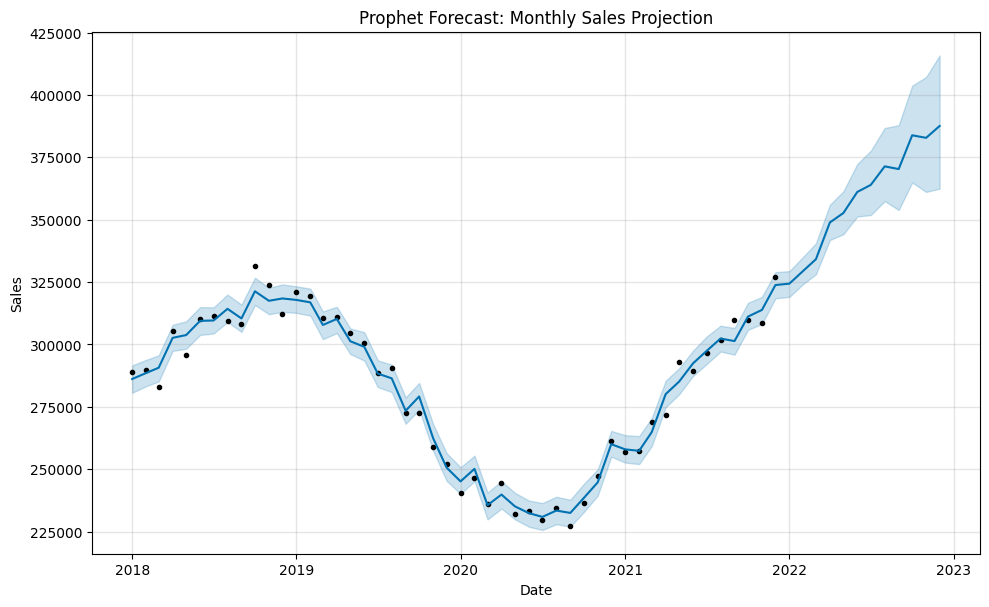

In [40]:
fig = model.plot(forecast)
plt.title("Prophet Forecast: Monthly Sales Projection")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# 🧾 Final Summary

### 📊 Model Accuracy:
- **MAE**: $51211.66
- **RMSE**: $60337.28
- **MAPE**: 17.08%

### 💰 Business Value:
- **Estimated Annual Holding Cost Savings**: $73744.80

The Prophet model effectively captured seasonality and long-term trends.  
Forecasts can support inventory planning, budgeting, and executive reporting.